# Metadata Field Distributions

Explore the distribution of metadata fields to determine normalization requirements for encoding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Fields to analyze
FIELDS = [
    'cadence_s',
    'Tmag',
    'sector',
    'dr3_parallax_zpt_corrected',
    'parallax_error',
    'G_0',
    'e_G_0',
    'BPRP0',
    'e_BPRP0',
    'mean_flux',
    'std_flux'
]

In [3]:
# Load metadata from h5 file
h5_path = Path('../data/timeseries_x.h5')

data = {}
with h5py.File(h5_path, 'r') as f:
    for field in FIELDS:
        if field in f['metadata']:
            data[field] = f['metadata'][field][:]
        else:
            print(f"Warning: {field} not found in metadata")

df = pd.DataFrame(data)
print(f"Loaded {len(df)} records")
df.head()

Loaded 7154 records


,cadence_s,Tmag,sector,dr3_parallax_zpt_corrected,parallax_error,G_0,e_G_0,BPRP0,e_BPRP0,mean_flux,std_flux
0,120.0,11.2277,42,6.559600,0.015855,11.681048,0.011626,1.023294,0.016744,5143.443848,17.129557
1,120.0,11.2277,43,6.559600,0.015855,11.681048,0.011626,1.023294,0.016744,5198.968262,20.664330
2,120.0,7.9191,43,21.744518,0.020119,8.404495,0.010005,0.900964,0.014187,111359.023438,206.402252
3,120.0,7.9191,44,21.744518,0.020119,8.404495,0.010005,0.900964,0.014187,106617.140625,462.201660
4,120.0,7.9191,70,21.744518,0.020119,8.404495,0.010005,0.900964,0.014187,107312.054688,406.109253


## Summary Statistics

In [4]:
# Compute summary statistics
stats = df.describe().T
stats['median'] = df.median()
stats['skew'] = df.skew()
stats['kurtosis'] = df.kurtosis()
stats['n_nan'] = df.isna().sum()
stats['pct_nan'] = (df.isna().sum() / len(df) * 100).round(2)

# Reorder columns
stats = stats[['count', 'n_nan', 'pct_nan', 'mean', 'std', 'median', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']]
stats

,count,n_nan,pct_nan,mean,std,median,min,25%,50%,75%,max,skew,kurtosis
cadence_s,7154.0,0,0.0,120.000000,0.000000e+00,120.000000,120.000000,120.000000,120.000000,120.000000,1.200000e+02,0.000000,0.000000
Tmag,7154.0,0,0.0,13.430879,2.542647e+00,13.881700,5.019600,11.825450,13.881700,15.415200,1.838760e+01,-0.728546,-0.044675
sector,7154.0,0,0.0,56.441851,1.820277e+01,45.000000,1.000000,44.000000,45.000000,71.000000,9.100000e+01,0.274608,-0.359591
dr3_parallax_zpt_corrected,7154.0,0,0.0,7.656225,4.092024e+00,7.188337,0.823390,5.540418,7.188337,7.475612,3.480038e+01,2.843876,7.635535
parallax_error,7154.0,0,0.0,0.060036,5.709488e-02,0.036449,0.008529,0.020250,0.036449,0.080280,5.276255e-01,2.049126,5.352742
G_0,7154.0,0,0.0,14.409007,2.920391e+00,15.016890,4.754343,12.484722,15.016890,16.728018,1.937579e+01,-0.740064,-0.104291
e_G_0,7154.0,0,0.0,0.015184,1.419301e-02,0.011423,0.010002,0.010080,0.011423,0.015441,4.647108e-01,14.182442,342.250312
BPRP0,7154.0,0,0.0,2.252283,9.883065e-01,2.570462,-0.262484,1.406167,2.570462,3.043600,5.027378e+00,-0.528523,-0.721972
e_BPRP0,7154.0,0,0.0,0.033573,3.301857e-02,0.021506,0.014155,0.015968,0.021506,0.036295,7.151772e-01,5.285111,64.205483
mean_flux,7154.0,0,0.0,30393.541016,1.037341e+06,433.100739,3.167623,105.563520,433.100739,3024.961548,8.731414e+07,83.315186,7010.340820


## Distribution Plots

Plot histograms for each field. Fields with high skewness may benefit from log transformation.

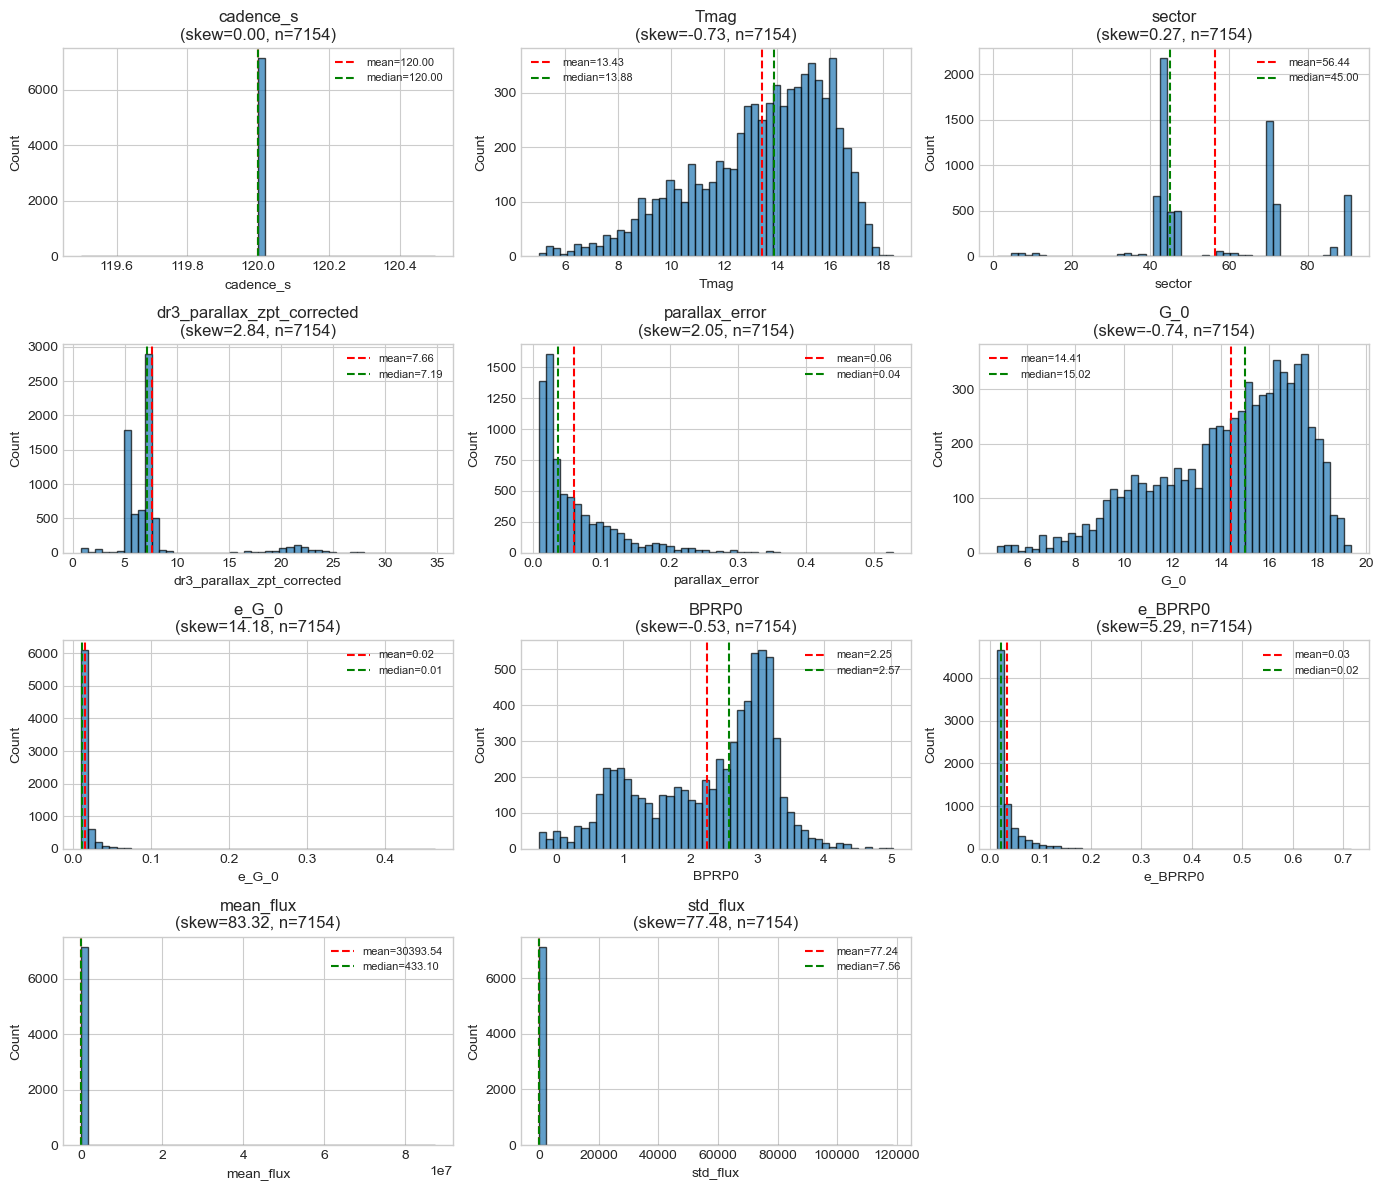

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, field in enumerate(FIELDS):
    ax = axes[i]
    values = df[field].dropna()
    
    ax.hist(values, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(values.mean(), color='red', linestyle='--', label=f'mean={values.mean():.2f}')
    ax.axvline(values.median(), color='green', linestyle='--', label=f'median={values.median():.2f}')
    
    ax.set_xlabel(field)
    ax.set_ylabel('Count')
    ax.set_title(f'{field}\n(skew={values.skew():.2f}, n={len(values)})')
    ax.legend(fontsize=8)

# Hide empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../output/metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Log-Transformed Distributions

For highly skewed fields, examine log-transformed distributions.

In [ ]:
# Fields that might benefit from log transform (typically positive-valued with high skew)
log_candidates = ['mean_flux', 'std_flux', 'parallax_error', 'e_G_0', 'e_BPRP0']

fig, axes = plt.subplots(2, len(log_candidates), figsize=(15, 6))

for i, field in enumerate(log_candidates):
    values = df[field].dropna()
    positive_values = values[values > 0]
    
    # Original
    axes[0, i].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{field}\n(original, skew={values.skew():.2f})')
    axes[0, i].set_xlabel(field)
    
    # Log-transformed
    if len(positive_values) > 0:
        log_values = np.log10(positive_values)
        axes[1, i].hist(log_values, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[1, i].set_title(f'log10({field})\n(skew={log_values.skew():.2f})')
        axes[1, i].set_xlabel(f'log10({field})')
    else:
        axes[1, i].text(0.5, 0.5, 'No positive values', ha='center', va='center')

axes[0, 0].set_ylabel('Count')
axes[1, 0].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../output/metadata_log_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Standardization Preview

Show what standardized (z-score) distributions would look like.

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

standardization_params = {}

for i, field in enumerate(FIELDS):
    ax = axes[i]
    values = df[field].dropna()
    
    # Standardize
    mean = values.mean()
    std = values.std()
    standardized = (values - mean) / std
    
    standardization_params[field] = {'mean': mean, 'std': std}
    
    ax.hist(standardized, bins=50, edgecolor='black', alpha=0.7, color='green')
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel(f'{field} (standardized)')
    ax.set_ylabel('Count')
    ax.set_title(f'{field}\n(range: [{standardized.min():.1f}, {standardized.max():.1f}])')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('../output/metadata_standardized.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Display standardization parameters
params_df = pd.DataFrame(standardization_params).T
params_df

## Correlation Matrix

Check for correlations between metadata fields.

In [ ]:
# Correlation matrix
corr = df[FIELDS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

# Add labels
ax.set_xticks(range(len(FIELDS)))
ax.set_yticks(range(len(FIELDS)))
ax.set_xticklabels(FIELDS, rotation=45, ha='right')
ax.set_yticklabels(FIELDS)

# Add correlation values
for i in range(len(FIELDS)):
    for j in range(len(FIELDS)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.colorbar(im, label='Correlation')
plt.title('Metadata Field Correlations')
plt.tight_layout()
plt.savefig('../output/metadata_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## Unique Values (for categorical-like fields)

In [ ]:
# Check unique values for sector and cadence_s (potentially categorical)
print("Sector unique values:")
print(sorted(df['sector'].unique()))
print(f"\nNumber of unique sectors: {df['sector'].nunique()}")

print("\n" + "="*50)
print("\nCadence unique values:")
print(sorted(df['cadence_s'].unique()))
print(f"\nNumber of unique cadences: {df['cadence_s'].nunique()}")

In [ ]:
# Value counts for categorical-like fields
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sector distribution
sector_counts = df['sector'].value_counts().sort_index()
axes[0].bar(sector_counts.index, sector_counts.values)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Count')
axes[0].set_title('Records per Sector')

# Cadence distribution
cadence_counts = df['cadence_s'].value_counts().sort_index()
axes[1].bar([str(c) for c in cadence_counts.index], cadence_counts.values)
axes[1].set_xlabel('Cadence (s)')
axes[1].set_ylabel('Count')
axes[1].set_title('Records per Cadence')

plt.tight_layout()
plt.show()

## Normalization Recommendations

In [ ]:
# Generate recommendations based on distribution analysis
recommendations = []

for field in FIELDS:
    values = df[field].dropna()
    skew = values.skew()
    n_unique = values.nunique()
    min_val = values.min()
    max_val = values.max()
    
    if n_unique <= 10:
        rec = "Categorical / One-hot encoding"
    elif abs(skew) > 2 and min_val > 0:
        rec = "Log transform + standardize"
    elif abs(skew) > 2:
        rec = "Consider robust scaling or quantile transform"
    elif abs(skew) > 1:
        rec = "Standardize (may benefit from log)"
    else:
        rec = "Standardize (z-score)"
    
    recommendations.append({
        'field': field,
        'skew': round(skew, 2),
        'n_unique': n_unique,
        'min': round(min_val, 4),
        'max': round(max_val, 4),
        'recommendation': rec
    })

rec_df = pd.DataFrame(recommendations)
rec_df